# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 07: MLP e CNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_07_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [2]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [4]:
# Carregando o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Ajustando dimensões dos rótulos
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Separando validação do treino
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Classes do dataset
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### <font color='#2D9CDB'>Q1) O dataset CIFAR-10 é amplamente utilizado em problemas de visão computacional e classificação de imagens. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o tipo de imagens que ela contém, a quantidade de classes existentes e alguns exemplos de objetos presentes nas imagens.</font>

O domínio da CIFAR-10 é a de classificação de imagens, criado como uma base de referência para treinar e testar algoritmos de ML. O dataset possui 60000 imagens de baixa resolução. Com 10 classes, 6000 imagens por classe, contendo coisas como animais(passáros, gatos etc) e meios de transporte(aviões, navios etc)

### <font color='#2D9CDB'>Q2) Exiba as dimensões dos conjuntos de treinamento, validação e teste, o formato das imagens, as dimensões dos vetores de rótulos e os valores únicos da variável alvo. Com base nos resultados obtidos, responda quantas imagens existem nos conjuntos de treinamento, validação e teste, qual é a resolução das imagens, quantos canais cada imagem possui e quantas classes diferentes existem no dataset.</font>

In [5]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print(x_train[0].shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)
print(np.unique(y_train))
print(len(np.unique(y_train)))

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)
(32, 32, 3)
(40000,)
(10000,)
(10000,)
[0 1 2 3 4 5 6 7 8 9]
10


São 40000 imagens para treinamento, 10000 para validação e 10000 para testes. Cada imagem possui a resolução 32x32 com todos os canais RGB e como dito antes, todas as imagens são englobadas dentro de 10 classes diferentes.

### <font color='#2D9CDB'>Q3) Plote as primeiras 25 imagens do conjunto de treinamento utilizando a função imshow, exibindo também o nome da classe correspondente a cada imagem. Organize as imagens em uma grade 5×5 e remova os eixos para melhorar a visualização. Em seguida, analise visualmente o dataset e discuta se as imagens parecem simples ou complexas para classificação, quais características tornam o problema mais desafiador e se existem classes visualmente semelhantes.</font>

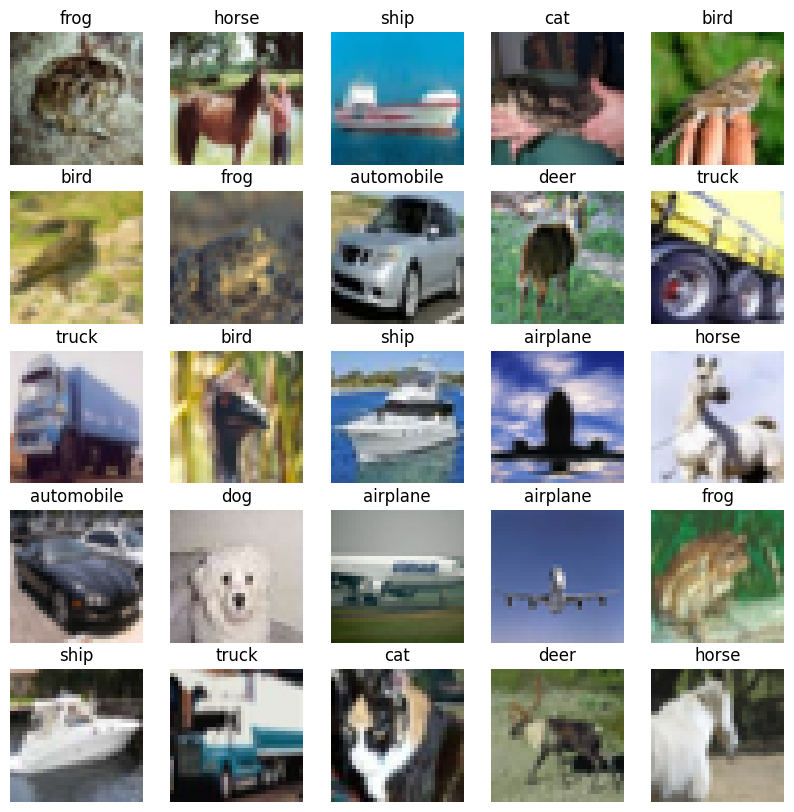

In [6]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

As imagens definitivamente não são fáceis de classificar devido a sua baixa resolução 32x32. Em casos de animais, é muito mais fácil se equivocar, tendo em vista que muitos partilham de caracteristicas semelhantes, como a imagem 2/4 de um veado que claramente lembra um cachorro.

### <font color='#2D9CDB'>Q4) Plote a distribuição das classes do conjunto de treinamento utilizando um gráfico de barras. Com base no gráfico obtido, analise se o dataset é balanceado ou desbalanceado, compare a quantidade de amostras entre as classes e discuta se o balanceamento das classes pode impactar o treinamento e o desempenho de uma rede neural.</font>

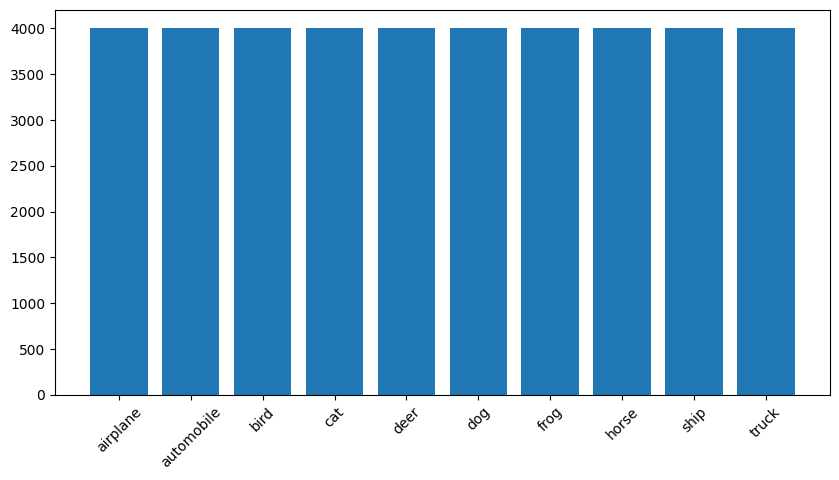

In [7]:
contagem = np.bincount(y_train)
plt.figure(figsize=(10, 5))
plt.bar(class_names, contagem)
plt.xticks(rotation=45)
plt.show()

Pelo gráfico, podemos perceber que o dataset se encontra muito bem balanceado, caracteristica essa que ajuda no aprendizado de máquina, tendo em vista que tudo será compreendido e testado com a mesma intencidade.

### <font color='#2D9CDB'>Q5) Verifique os valores mínimo e máximo dos pixels das imagens do conjunto de treinamento. Em seguida, normalize os conjuntos de treino, validação e teste dividindo os valores dos pixels por 255. Após a normalização, verifique novamente os valores mínimo e máximo e explique por que esse procedimento é importante para o treinamento de redes neurais profundas. Discuta também como a normalização influencia a estabilidade numérica do treinamento e a velocidade de convergência do algoritmo de otimização.</font>

In [8]:
print(x_train.min())
print(x_train.max())
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0
print(x_train.min())
print(x_train.max())

0
255
0.0
1.0


A normalização é importante porque transforma os valores dos pixels de 0 a 255, para uma escala entre 0 e 1, facilitando o o treinamento, já que as entradas são menores, os cálculos realizados durante o treinamento ficam mais seguros, reduzindo problemas como instabilidade. Além disso, a normalização ajuda o algoritmo de otimização, como o gradiente descendente, a convergir mais rapidamente.

### <font color='#2D9CDB'>Q6) Explique por que as imagens do CIFAR-10 podem ser representadas como tensores tridimensionais. Em seguida, identifique o significado de cada dimensão do tensor (32, 32, 3), explique o papel dos canais RGB e discuta a diferença entre imagens coloridas e imagens em tons de cinza no contexto de redes neurais convolucionais.</font>

As imagens são representadas como tensores tridimensionais porque possuem altura, largura e canais de cor, formato 32 32, 3, o primeiro 32 representa a altura, o segundo representa a largura e o 3 representa os canais RGb,permitindo formar imagens coloridas combinando diferentes intensidades. Em tons de cinza, existe apenas um canal, pois cada pixel representa somente a intensidade de luz, redes neurais convolucionais, imagens coloridas oferecem mais informações visuais, enquanto imagens em tons de cinza são mais simples e exigem menos processamento.

# <font color='green'><u><b>Parte 2 - MLP</b></u></font>

### <font color='#2D9CDB'>Q7) As redes neurais do tipo Multilayer Perceptron (MLP) utilizam camadas densamente conectadas e, portanto, esperam vetores unidimensionais como entrada. Explique por que é necessário transformar as imagens do CIFAR-10 antes de utilizá-las em uma MLP e discuta o que acontece com a estrutura espacial das imagens durante esse processo. Em seguida, construa uma rede neural MLP utilizando a API Sequential do Keras com uma camada Flatten, duas camadas densas escondidas com função de ativação ReLU e uma camada de saída com 10 neurônios e ativação Softmax.</font>

In [13]:
modelo_mlp = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

modelo_mlp.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

Para uma MLP entender os dados, ele precisa estar em formato de vetor, por isso as imagens que estão em 32, 32, 3 precisam se tornar vetores unidimensionais, a camada Flatten faz essa transformação, convertendo cada imagem em um vetor e,durante esse processo, a estrutura espacial da imagem é perdida.

### <font color='#2D9CDB'>Q8) Exiba o resumo da arquitetura da rede neural criada utilizando o método summary() e analise a quantidade de parâmetros treináveis da MLP. Com base nas dimensões das imagens do CIFAR-10 e no número de neurônios utilizados nas camadas densas, discuta por que MLPs podem rapidamente se tornar modelos muito grandes para problemas de classificação de imagens.</font>

In [10]:
modelo_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

A camada flatten é capaz de transformar o formato 32,32, 3 em um vetor com 3072 entradas, a quantidade de camadas entrelaçadas e densas trocando pesos faz com que o modelo possa se tornar muito grande em pouco tempo, especialmente quando a resolução aumenta.

### <font color='#2D9CDB'>Q9) Compile a MLP utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, explique o papel da função de custo durante o treinamento, o objetivo do algoritmo de otimização e por que a combinação entre Softmax e entropia cruzada é adequada para problemas de classificação multiclasse.</font>

In [ ]:
modelo_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

A função de custo mede o quanto as previsões do modelo estão erradas em relação as classes corretas. Com o treinamento, o objetivo é reduzir esse erro. O otimizador Adam ajusta os pesos da rede a cada época, tentando minimizar a função de custo de forma eficiente. A combinação entre Softmax e entropia cruzada é adequada para classificação multiclasse porque a Softmax transforma a saída da rede em probabilidades para cada uma das 10 classes, enquanto a sparse_categorical_crossentropy compara essas probabilidades com o rótulo correto e penaliza previsões incorretas. Como os rótulos do CIFAR-10 estão em formato numérico, como 0, 1, 2 até 9, a versão sparse é apropriada.

### <font color='#2D9CDB'>Q10) Treine a rede neural por 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History e, em seguida, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação. Após gerar os gráficos, analise o comportamento do treinamento, discutindo se o modelo aparenta convergir adequadamente, se há estabilidade durante o treinamento e se existem indícios de overfitting.</font>

In [ ]:
modelo_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
historico_mlp = modelo_mlp.fit(
    x_train,
    y_train,
    epochs=25,
    validation_data=(x_val, y_val)
)

plt.figure(figsize=(8, 5))
plt.plot(historico_mlp.history['loss'], label='Treino')
plt.plot(historico_mlp.history['val_loss'], label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.figure(figsize=(8, 5))
plt.plot(historico_mlp.history['accuracy'], label='Treino')
plt.plot(historico_mlp.history['val_accuracy'], label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.3116 - loss: 1.8958 - val_accuracy: 0.3272 - val_loss: 1.8546
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.3822 - loss: 1.7152 - val_accuracy: 0.3937 - val_loss: 1.6767
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4135 - loss: 1.6318 - val_accuracy: 0.4207 - val_loss: 1.6336
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.4350 - loss: 1.5762 - val_accuracy: 0.4329 - val_loss: 1.5980
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4489 - loss: 1.5352 - val_accuracy: 0.4340 - val_loss: 1.5929
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.4612 - loss: 1.5056 - val_accuracy: 0.4527 - val_loss: 1.5527
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4683 - loss: 1.4797 - val_accuracy: 0.4464 - val_loss: 1.5547
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4765 -

### <font color='#2D9CDB'>Q11) Avalie o desempenho da MLP utilizando o conjunto de teste e reporte os valores de loss e accuracy obtidos. Em seguida, compare os resultados dos conjuntos de treinamento e teste e discuta se o modelo aparenta apresentar boa capacidade de generalização.</font>

### <font color='#2D9CDB'>Q12) Utilize a MLP treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita pelo modelo e compare-a com a classe verdadeira da imagem. Com base nas probabilidades obtidas, explique o significado da saída Softmax e discuta se o modelo está realizando previsões com alta ou baixa confiança.</font>

### <font color='#2D9CDB'>Q13) Plote a matriz de confusão da MLP utilizando o conjunto de teste. Em seguida, identifique quais classes foram mais confundidas pelo modelo e discuta possíveis razões para esses erros de classificação, considerando as limitações de uma arquitetura MLP aplicada a problemas de visão computacional.</font>

### <font color='#2D9CDB'>Q14) Com base nos resultados obtidos ao longo desta etapa, discuta as principais vantagens e limitações das redes MLP para classificação de imagens. Em sua resposta, considere aspectos como preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização e desempenho obtido no CIFAR-10.</font>

# <font color='green'><u><b>Parte 3 - CNN</b></u></font>

### <font color='#2D9CDB'>Q15) As redes neurais convolucionais (CNNs) foram desenvolvidas para lidar melhor com dados que possuem estrutura espacial, como imagens. Explique por que arquiteturas MLP apresentam limitações em problemas de visão computacional e descreva como as CNNs conseguem preservar relações espaciais entre os pixels. Em seguida, explique os conceitos de convolução, filtros convolucionais e mapas de características (feature maps).</font>

### <font color='#2D9CDB'>Q16) Construa uma rede neural convolucional utilizando a API Sequential do Keras. A arquitetura da CNN deve conter camadas Conv2D com ativação ReLU, camadas MaxPooling2D, uma camada Flatten e uma camada de saída com 10 neurônios e ativação Softmax. Após construir a arquitetura, explique o papel das camadas convolucionais, das camadas de pooling e da camada Flatten dentro da CNN.</font>

### <font color='#2D9CDB'>Q17) Exiba o resumo da arquitetura da CNN utilizando o método summary() e compare a quantidade de parâmetros treináveis da CNN com a da MLP construída anteriormente. Em seguida, discuta por que CNNs costumam ser mais eficientes para classificação de imagens, mesmo utilizando menos parâmetros treináveis.</font>

### <font color='#2D9CDB'>Q18) Compile a CNN utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, treine o modelo por até 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History. Após o treinamento, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação e analise o comportamento do treinamento da CNN.</font>

### <font color='#2D9CDB'>Q19) Avalie o desempenho da CNN utilizando o conjunto de teste e compare os resultados obtidos com aqueles alcançados pela MLP. Em seguida, discuta as diferenças observadas em termos de accuracy, capacidade de generalização e aprendizado de características visuais.</font>

### <font color='#2D9CDB'>Q20) Utilize a CNN treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita e compare-a com a classe verdadeira da imagem. Em seguida, analise se a CNN aparenta realizar previsões mais confiantes que a MLP e discuta possíveis razões para esse comportamento.</font>

### <font color='#2D9CDB'>Q21) Plote a matriz de confusão da CNN utilizando o conjunto de teste e compare-a com a matriz de confusão obtida pela MLP. Identifique quais classes apresentaram melhora significativa de classificação e discuta por que CNNs conseguem reduzir confusões entre classes visualmente semelhantes.</font>

### <font color='#2D9CDB'>Q22) Adicione camadas Dropout à CNN e treine novamente o modelo. Em seguida, plote as curvas de loss e accuracy para os conjuntos de treinamento e validação e compare os resultados com a CNN original. Com base nos gráficos obtidos, discuta o impacto do Dropout no overfitting e na capacidade de generalização da rede neural.</font>

### <font color='#2D9CDB'>Q23) Com base em todos os resultados obtidos ao longo da atividade, compare as arquiteturas MLP e CNN para classificação de imagens. Em sua resposta, discuta diferenças relacionadas à preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização, desempenho obtido no CIFAR-10 e adequação de cada arquitetura para problemas de visão computacional.</font>